# Task - 5 : Classification Tasks Overview

## Task - 1 : Student Pass/Fail Prediction

### 1. Dataset Selection:

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

#### The dataset student_pass_fail.csv is loaded to analyze student performance. The first five rows are displayed to provide an overview of study hours, attendance, and pass/fail outcomes.

In [8]:
df=pd.read_csv("student_pass_fail.csv")
print(df.head())

   Study Hours  Attendance  Pass
0            7          40     0
1           15          86     1
2           11          79     1
3            8          52     0
4            7          60     0


### 2. Tasks to Perform:

#### The analysis identifies missing values, detects outliers in study hours and attendance, and visualizes the relationship between these factors and student performance using scatter and pair plots.


Missing Values:
 Study Hours    0
Attendance     0
Pass           0
dtype: int64


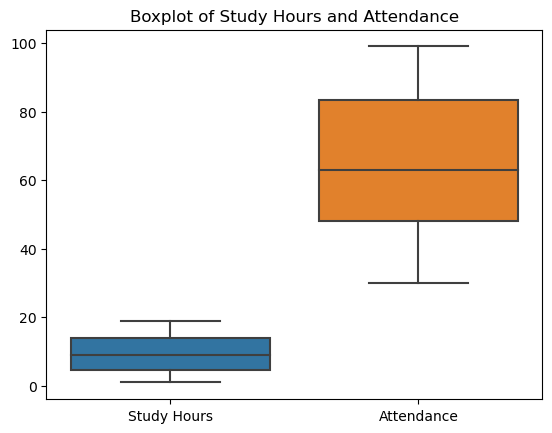

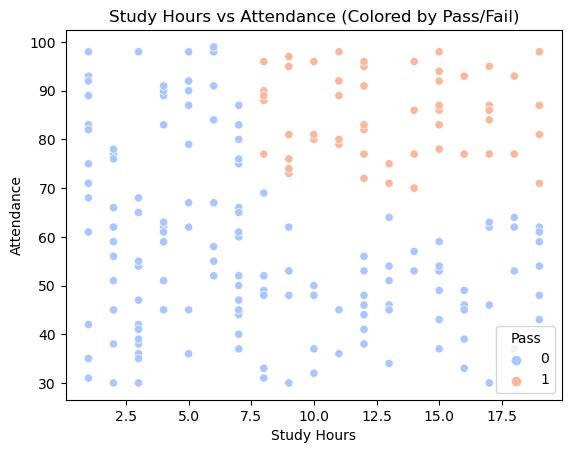

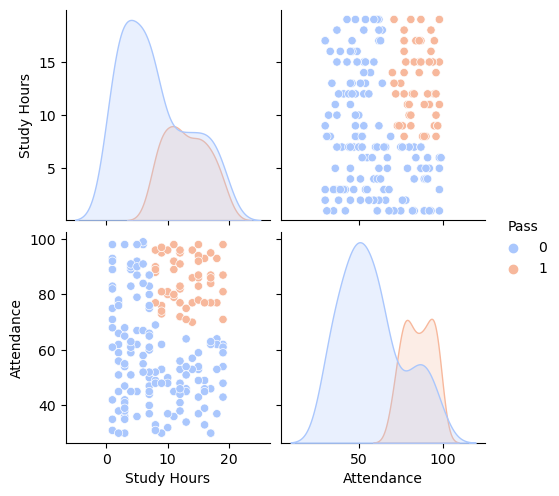

In [9]:
print("\nMissing Values:\n", df.isnull().sum())

sns.boxplot(data=df[['Study Hours', 'Attendance']])
plt.title("Boxplot of Study Hours and Attendance")
plt.show()

sns.scatterplot(x=df['Study Hours'], y=df['Attendance'], hue=df['Pass'], palette='coolwarm')
plt.title("Study Hours vs Attendance (Colored by Pass/Fail)")
plt.show()

sns.pairplot(df, hue="Pass", diag_kind="kde", palette="coolwarm")
plt.show()

#### The dataset is split into training and testing sets, followed by feature scaling to standardize study hours and attendance. A logistic regression model is then trained to predict student pass/fail outcomes.

In [10]:
X = df[['Study Hours', 'Attendance']]
y = df['Pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

#### The trained model predicts student pass/fail outcomes on the test data, and its accuracy is evaluated. A confusion matrix is then displayed to analyze the model's classification performance.


Model Accuracy: 0.93


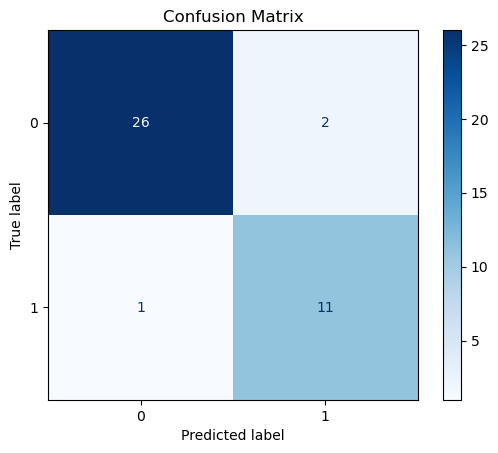

In [11]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")

cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Task 2: Sentiment Analysis with Natural Language Processing

### 1. Dataset Selection

In [26]:
pip install pandas scikit-learn nltk

In [27]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [28]:
df = pd.read_csv("reviews.csv") 

In [32]:
!pip install nltk scikit-learn pandas 

import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [36]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

df = pd.read_csv("review.csv", encoding='utf-8', on_bad_lines='skip')
print(df.head(10))

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
5  Probably my all-time favorite movie, a story o...  positive
6  I sure would like to see a resurrection of a u...  positive
7  This show was an amazing, fresh & innovative i...  negative
8  Encouraged by the positive comments about this...  negative
9  If you like original gut wrenching laughter yo...  positive


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### 2. Tasks to Perform

#### his checks if the dataset has the required columns, raises an error if they are missing, and removes any rows with missing values in those columns.

In [37]:
if 'review' not in df.columns or 'sentiment' not in df.columns:
    raise ValueError("Dataset must have 'review' and 'sentiment' columns.")
df.dropna(subset=['review', 'sentiment'], inplace=True)

#### Text data is cleaned and prepared by standardizing case, removing unwanted characters, and refining words through tokenization and lemmatization. The dataset is then updated with these processed reviews, and sentiment labels are transformed into numerical values for model training.

In [38]:
def preprocess_text(text):
    text = str(text).lower() 
    text = re.sub(r'[^\w\s]', '', text)  
    tokens = word_tokenize(text) 
    tokens = [word for word in tokens if word not in stopwords.words('english')]  
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens] 
    return ' '.join(tokens)

df['processed_review'] = df['review'].apply(preprocess_text)
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [43]:
X_train, X_test, y_train, y_test = train_test_split(df['processed_review'], df['sentiment'], test_size=0.2, random_state=42)
vectorizer = TfidfVectorizer(max_features=200) 
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [44]:
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

LogisticRegression()

#### The trained model predicts sentiments for the test data, and the predictions are evaluated using accuracy, precision, recall, and F1-score to measure overall performance.

In [45]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [46]:
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Accuracy: 0.70
Precision: 0.77
Recall: 0.63
F1-Score: 0.69
